### **Налаштування середовища**



In [1]:
# Імпорт бібліотек для Deep Learning, маніпуляцій з даними та логування
import wandb
import os
import math
import time
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as T
from torchvision.datasets import STL10
from torchvision.models import resnet18

# Функція для відтворення результатів (фіксація випадкових чисел)
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

SEED = 42
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## **Гіперпараметри**

In [2]:
@dataclass
class CFG:
    data_root: str = "./data"

    # SimCLR pretrain
    pretrain_epochs: int = 50
    pretrain_batch_size: int = 256
    pretrain_lr: float = 3e-4
    pretrain_weight_decay: float = 1e-4
    temperature: float = 0.2

    # Linear evaluation
    linear_epochs: int = 30
    linear_batch_size: int = 256
    linear_lr: float = 1e-3
    linear_weight_decay: float = 0.0


    # Logging
    out_dir: str = "./outputs_simclr"
    project_name: str = "stl10-simclr"
    run_name: str = "simclr_resnet18"

cfg = CFG()
Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)
print(cfg)


CFG(data_root='./data', pretrain_epochs=50, pretrain_batch_size=256, pretrain_lr=0.0003, pretrain_weight_decay=0.0001, temperature=0.2, linear_epochs=30, linear_batch_size=256, linear_lr=0.001, linear_weight_decay=0.0, out_dir='./outputs_simclr', project_name='stl10-simclr', run_name='simclr_resnet18')


## **Аугментації зображень**

In [3]:
# Цей клас готує два варіанти одного зображення (xi, xj)
# для навчання моделі порівнювати їх між собою.
class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        image, _ = self.dataset[index]
        xi = self.transform(image)
        xj = self.transform(image)
        return xi, xj

    def __len__(self):
        return len(self.dataset)

In [4]:
# щоб модель навчилася розпізнавати об'єкт навіть у зміненому вигляді:
simclr_transform = T.Compose([
    T.RandomResizedCrop(96, scale=(0.2, 1.0), ratio=(0.75, 1.3333), antialias=True),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0))], p=0.5),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

train_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

## **Завантаження даних**

In [5]:
# 1. Завантаження нерозмічених даних (100 000 зображень) для навчання без вчителя (Self-Supervised Learning)
unlabeled_base = STL10(root=cfg.data_root, split="unlabeled", download=True,transform=None)

# 2. Обгортання датасету в SimCLRDataset:
# Кожна картинка тепер генерує дві різні аугментовані версії (x1, x2),
# що є основою контрастивного навчання
unlabeled_ds = SimCLRDataset(unlabeled_base, simclr_transform)

# 3. Завантаження розмічених даних (тренувальний та тестовий набори) для подальшої оцінки точності (Linear Evaluation)
labeled_train_full = STL10(root=cfg.data_root, split="train", download=True, transform=train_transform)
test_ds = STL10(root=cfg.data_root, split="test", download=True, transform=test_transform)

# 4. Створення функції для розбиття набору даних на тренувальну та валідаційну вибірки
# Це критично для того, щоб модель не "перенавчалася" (overfitting)
VAL_SIZE = 500

def make_splits(num_train, val_size, seed):
    rng = np.random.default_rng(seed)
    all_idx = np.arange(num_train)
    rng.shuffle(all_idx)
    val_idx = all_idx[:val_size]
    train_idx = all_idx[val_size:]
    return {"train_labeled": train_idx, "val_labeled": val_idx}

# 5. Застосування розбиття: створюємо Subset (підмножину) для навчання та валідації
splits = make_splits(len(labeled_train_full), VAL_SIZE, SEED)
train_idx = splits["train_labeled"]
val_idx = splits["val_labeled"]
train_labeled_ds = torch.utils.data.Subset(labeled_train_full, train_idx)
val_labeled_ds = torch.utils.data.Subset(labeled_train_full, val_idx)

# 6. Вивід статистики для перевірки коректності завантаження даних
print("unlabeled:", len(unlabeled_ds))
print("train_labeled:", len(train_labeled_ds))
print("val_labeled:", len(val_labeled_ds))
print("test:", len(test_ds))



100%|██████████| 2.64G/2.64G [01:20<00:00, 32.9MB/s]


unlabeled: 100000
train_labeled: 4500
val_labeled: 500
test: 8000


In [6]:
# pretrain_loader: головний завантажувач для навчання без вчителя.
# drop_last=True критично важливо для SimCLR, щоб кожен батч мав однаковий розмір
# для коректного обчислення контрастивної функції втрат.
pretrain_loader = DataLoader(unlabeled_ds, batch_size=cfg.pretrain_batch_size, shuffle=True, drop_last=True)

# Завантажувачі для етапу лінійної оцінки (Linear Evaluation).
# Тут ми використовуємо вже розмічені дані, щоб перевірити,
# як добре encoder навчився розрізняти класи
train_loader = DataLoader(train_labeled_ds, batch_size=cfg.linear_batch_size, shuffle=True)
val_loader = DataLoader(val_labeled_ds, batch_size=cfg.linear_batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=cfg.linear_batch_size, shuffle=False)

## **Архітектура SimCLR та функція втрат (NT-Xent)**

In [7]:
class SimCLRModel(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        # ResNet-18 як основа для виділення візуальних ознак
        base_model = resnet18(weights=None)
        num_f = base_model.fc.in_features
        # заміна останнього шару класифікації на Identity, бо нам потрібні "сирі" ознаки
        base_model.fc = nn.Identity()
        self.encoder = base_model
        # Проєкційна голова переводить вектори ознак у простір меншої розмірності,
        # де модель вчиться контрастивним методам (виділення спільних рис)
        self.projection_head = nn.Sequential(
            nn.Linear(num_f, 512),
            nn.ReLU(),
            nn.Linear(512, proj_dim)
        )

    def forward(self, x):
        h = self.encoder(x) # виділені ознаки
        z = self.projection_head(h) # проєкція для контрастивного навчання
        return h, z

# NT-Xent (Normalized Temperature-scaled Cross Entropy Loss)
# модель "штрафується", якщо схожі картинки (позитивні пари)
# знаходяться далеко одна від одної, і "нагороджується", якщо вони поруч
def nt_xent_loss(z1, z2, temperature=0.2):
    B, D = z1.shape
    z1 = F.normalize(z1, dim=1) # Нормалізація векторів на одиничну сферу
    z2 = F.normalize(z2, dim=1)
    z = torch.cat([z1, z2], dim=0)  # обидва види аугментацій в один батч (2B)

    # Обчислюємо матрицю схожості (скалярний добуток) між усіма зразками
    sim = torch.matmul(z, z.T) / temperature

    # mask self-similarity
    mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -1e9) # Видаляємо схожість з самим собою

    # Витягуємо позитивні пари (збіги)
    pos = torch.cat([torch.diag(sim, B), torch.diag(sim, -B)], dim=0)  # (2B,)

    denom = torch.logsumexp(sim, dim=1)  # нормалізація через LogSumExp (стабілізація)
    loss = (-pos + denom).mean() # підсумкова помилка
    return loss

# ініціалізація моделі
simclr = SimCLRModel(proj_dim=128).to(device)
print("SimCLR trainable params:", sum(p.numel() for p in simclr.parameters() if p.requires_grad))


SimCLR trainable params: 11504832


In [8]:
# Функція оцінки моделі (Linear Evaluation)
# фуксуються ваги енкодера і навчається лише лише лінійний класифікатор поверх нього
# @torch.no_grad() вимикає обчислення градієнтів, щоб заощадити пам'ять і прискорити роботу
@torch.no_grad()
def evaluate_linear(encoder, clf, loader):
    encoder.eval() # Переводимо в режим оцінки (вимикає Dropout/BatchNorm)
    clf.eval()
    correct, total = 0, 0

    num_classes = 10
    # Масиви для розрахунку метрик якості за класами:
    # TP (True Positive), FP (False Positive), FN (False Negative)
    tp = torch.zeros(num_classes, device=device)
    fp = torch.zeros(num_classes, device=device)
    fn = torch.zeros(num_classes, device=device)

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        h = encoder(x) # ознаки з навченого енкодера
        logits = clf(h) # пропускаємо через класифікатор
        preds = logits.argmax(dim=1) # обираємо клас з найвищою ймовірністю

        correct += (preds == y).sum().item()
        total += y.numel()

        # обчислення метрик для кожного класу окремо
        for c in range(num_classes):
            tp[c] += ((preds == c) & (y == c)).sum()
            fp[c] += ((preds == c) & (y != c)).sum()
            fn[c] += ((preds != c) & (y == c)).sum()
    # розрахунок підсумкових метрик: Accuracy (точність) та F1-Score (середня якість)
    acc = correct / max(total, 1)
    precision = tp / (tp + fp + 1e-9) # 1e-9 щоб уникнути ділення на нуль
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    macro_f1 = f1.mean().item()
    return acc, macro_f1

# функції для збереження та завантаження чекпоінтів моделі
def save_ckpt(path: Path, **kwargs):
    torch.save(kwargs, str(path))
    # зберігає ваги моделі та стан оптимізатора, щоб мати змогу відновити навчання
def load_ckpt(path: Path, map_location=None):
    # відновлює ваги з диска для подальшого тестування або донавчання
    return torch.load(str(path), map_location=map_location)

### **Основний цикл навчання та моніторинг (Pretraining)**
У цій клітинці відбувається ітеративне навчання моделі з використанням контрастивної функції втрат (NT-Xent).
Реалізовано:
- **Cosine LR Scheduler**: плавне зниження швидкості навчання для кращої збіжності.
- **W&B Logging**: трекінг метрик у реальному часі.
- **Cloud Persistence**: автоматичне збереження найкращих ваг моделі та історії втрат (Loss History) на Google Drive для запобігання втраті даних.

In [ ]:
from tqdm.auto import tqdm
from google.colab import drive
import shutil
import pandas as pd

# 1. Монтуємо диск
drive.mount('/content/drive')

# 2. Шляхи для збереження
simclr_ckpt_path = Path(cfg.out_dir) / "simclr_pretrained.pth"
drive_ckpt_path = "/content/drive/MyDrive/simclr_pretrained.pth"
loss_history_path = "/content/drive/MyDrive/loss_history.csv" # Таблиця з втратами

pretrain_opt = optim.AdamW(simclr.parameters(), lr=cfg.pretrain_lr, weight_decay=cfg.pretrain_weight_decay)

def cosine_lr(step, total_steps, base_lr):
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * step / total_steps)) #learning rate starts by base_lr and smoothly decreases to 0

total_steps = cfg.pretrain_epochs * len(pretrain_loader)



wandb.init(project=cfg.project_name, name=cfg.run_name + "_pretrain", config=cfg.__dict__)

best_pretrain_loss = float("inf")
loss_history = []
simclr_ckpt_path = Path(cfg.out_dir) / "simclr_pretrained.pth"

global_step = 0
for epoch in range(1, cfg.pretrain_epochs + 1):
    simclr.train()
    t0 = time.time()
    running = 0.0

    for x1, x2 in tqdm(pretrain_loader):
        x1 = x1.to(device, non_blocking=True)
        x2 = x2.to(device, non_blocking=True)

        pretrain_opt.zero_grad(set_to_none=True)

        _, z1 = simclr(x1)
        _, z2 = simclr(x2)
        loss = nt_xent_loss(z1, z2, temperature=cfg.temperature)

        loss.backward()
        pretrain_opt.step()


        lr = cosine_lr(global_step, total_steps, cfg.pretrain_lr) # upd LR according to cosine schedule
        for pg in pretrain_opt.param_groups:
            pg["lr"] = lr

        running += loss.item()
        global_step += 1

    avg_loss = running / max(len(pretrain_loader), 1)
    dt = time.time() - t0

    # Зберігаємо дані в список для таблички
    loss_history.append({'epoch': epoch, 'loss': avg_loss})

    # Зберігаємо табличку на диск після кожної епохи (якщо впаде — дані залишаться)
    pd.DataFrame(loss_history).to_csv(loss_history_path, index=False)

    wandb.log({"pretrain/loss": avg_loss, "pretrain/lr": lr, "epoch": epoch})

    print(f"[pretrain] epoch {epoch:03d}/{cfg.pretrain_epochs} loss={avg_loss:.4f} time={dt:.1f}s")

    if avg_loss < best_pretrain_loss:
        best_pretrain_loss = avg_loss
        save_ckpt(simclr_ckpt_path, epoch=epoch, simclr_state=simclr.state_dict(), cfg=cfg.__dict__)
        shutil.copy(simclr_ckpt_path, drive_ckpt_path) # Копія моделі на диск
        print("  saved:", simclr_ckpt_path)

print("Best pretrain loss:", best_pretrain_loss)


In [10]:
# Клітинка для перевірки цілісності даних (Data Sanity Check)
# Ми витягуємо один батч, щоб побачити структуру тензорів перед початком тренування.
batch = next(iter(pretrain_loader))
print("Тип батчу:", type(batch), "| Кількість елементів:", len(batch))
print("Типи даних в батчі:", [type(b) for b in batch])

# SimCLR очікує пари зображень (x1, x2).
# Якщо структура даних правильна, ми побачимо тензори потрібного розміру:
# [batch_size, 3, 96, 96]
if isinstance(batch[0], (tuple, list)):
    (x1, x2), y = batch
    print("Структура з мітками: x1", x1.shape, "x2", x2.shape, "y", y.shape)
else:
    x1, x2 = batch
    print("Структура без міток (SimCLR): x1", x1.shape, "x2", x2.shape)


Тип батчу: <class 'list'> | Кількість елементів: 2
Типи даних в батчі: [<class 'torch.Tensor'>, <class 'torch.Tensor'>]
Структура без міток (SimCLR): x1 torch.Size([256, 3, 96, 96]) x2 torch.Size([256, 3, 96, 96])


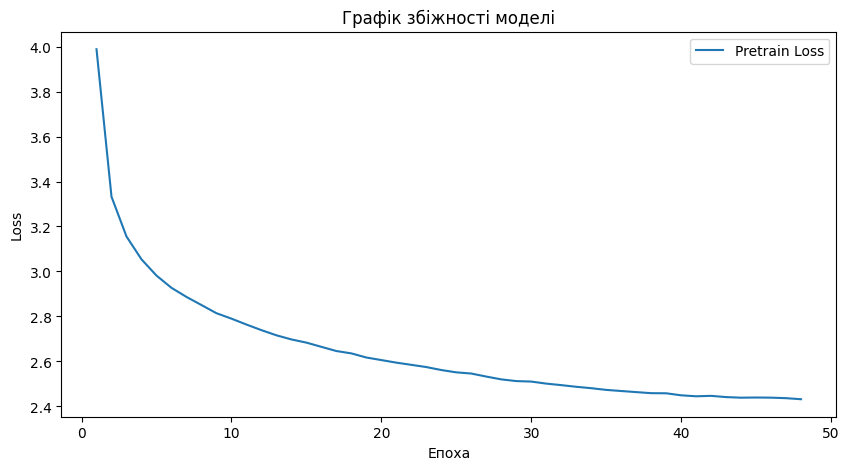

In [11]:
import matplotlib.pyplot as plt

df = pd.read_csv(loss_history_path)
plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['loss'], label='Pretrain Loss')
plt.title('Графік збіжності моделі')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
from tqdm.auto import tqdm
from google.colab import drive
import shutil
import pandas as pd

# 1. Монтуємо диск
drive.mount('/content/drive')

# 2. Шляхи для збереження
simclr_ckpt_path = Path(cfg.out_dir) / "simclr_pretrained.pth"
drive_ckpt_path = "/content/drive/MyDrive/simclr_pretrained.pth"
loss_history_path = "/content/drive/MyDrive/loss_history.csv" # Таблиця з втратами

Mounted at /content/drive
